In [1]:
# ============================================================
# 🔧 Sistema, utilidades y visualización
# ============================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from the_well.data import WellDataset
 
# ============================================================
# 1. DEFINICIÓN DE DATASETS
# ============================================================
BASE_PATH = "/home/itachi/Desktop/msc/data/datasets"
 
dataset_kwargs = {
    "well_base_path": BASE_PATH,
    "well_dataset_name": "active_matter",
    "n_steps_input": 1,
    "n_steps_output": 0,
    "use_normalization": True,
}
 
train_dataset = WellDataset(**dataset_kwargs, well_split_name="train")
eval_dataset  = WellDataset(**dataset_kwargs, well_split_name="valid")
 
print(f"📊 Samples -> Train: {len(train_dataset)}, Eval: {len(eval_dataset)}")
sample = train_dataset[0]
print(f"✅ Dataset OK, shape: {sample['input_fields'].shape}")
 
# ============================================================
# 2. DATA LOADERS
# ============================================================
BATCH_SIZE = 128
PIN_MEMORY = True
 
# num_workers=0: HDF5 no es thread-safe con fork()
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=PIN_MEMORY,
)
eval_loader = DataLoader(
    eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=PIN_MEMORY,
)
 
# ============================================================
# 3. MAPA DE CANALES (confirmado con train_dataset.metadata)
# ============================================================
# Índice | Campo         | Rango     | Normalización  | Activación
# -------|---------------|-----------|----------------|----------
#   0    | concentration | [0, 1]    | Min-Max        | sigmoid
#   1    | velocity_x    | simétrico | abs-max        | tanh
#   2    | velocity_y    | simétrico | abs-max        | tanh
#   3    | D_xx          | [0, 1]    | Min-Max        | sigmoid
#   4    | D_xy          | simétrico | abs-max        | tanh
#   5    | D_yx          | simétrico | abs-max        | tanh
#   6    | D_yy          | [0, 1]    | Min-Max        | sigmoid
#   7    | E_xx          | simétrico | abs-max        | tanh
#   8    | E_xy          | simétrico | abs-max        | tanh
#   9    | E_yx          | simétrico | abs-max        | tanh
#  10    | E_yy          | simétrico | abs-max        | tanh
 
POSITIVE_CHANNELS  = [0, 3, 6]
SYMMETRIC_CHANNELS = [1, 2, 4, 5, 7, 8, 9, 10]
 
CHANNEL_NAMES = [
    "concentration",
    "velocity_x", "velocity_y",
    "D_xx", "D_xy", "D_yx", "D_yy",
    "E_xx", "E_xy", "E_yx", "E_yy",
]
 
# ============================================================
# 4. PREPROCESAMIENTO
# ============================================================
def fast_preprocess(batch, device):
    """
    Normaliza cada canal según su tipo físico:
    - Canales positivos  [0, 3, 6]: Min-Max → [0, 1]
    - Canales simétricos [resto]:   abs-max → [-1, 1]
    Entrada:  batch["input_fields"] con shape (B, 1, H, W, 11)
    Salida:   tensor (B, 11, H, W) en device
    """
    x = batch["input_fields"].to(device, non_blocking=True).squeeze(1)
    out = torch.empty_like(x)
 
    for c in POSITIVE_CHANNELS:
        ch   = x[..., c]
        flat = ch.reshape(ch.size(0), -1)
        cmin = flat.min(dim=1)[0].view(-1, 1, 1)
        cmax = flat.max(dim=1)[0].view(-1, 1, 1)
        out[..., c] = (ch - cmin) / (cmax - cmin + 1e-7)
 
    for c in SYMMETRIC_CHANNELS:
        ch   = x[..., c]
        flat = ch.reshape(ch.size(0), -1)
        vmax = flat.abs().max(dim=1)[0].view(-1, 1, 1)
        out[..., c] = ch / (vmax + 1e-7)
 
    return out.permute(0, 3, 1, 2).contiguous()    # (B, 11, H, W)
 
# ============================================================
# 5. DIAGNÓSTICO: estadísticas por canal
# ============================================================
def print_channel_stats(tensor, label=""):
    print(f"\n{'='*65}")
    print(f"  {label}  |  shape: {tuple(tensor.shape)}")
    print(f"{'='*65}")
    print(f"  {'Canal':<15} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
    print(f"  {'-'*57}")
    for c in range(tensor.size(1)):
        flat = tensor[:, c, :, :].reshape(tensor.size(0), -1)
        print(f"  {CHANNEL_NAMES[c]:<15} "
              f"{flat.min(dim=1)[0].mean().item():>10.5f} "
              f"{flat.max(dim=1)[0].mean().item():>10.5f} "
              f"{flat.mean(dim=1).mean().item():>10.5f} "
              f"{flat.std(dim=1).mean().item():>10.5f}")
    print(f"{'='*65}")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Usando dispositivo: {device}")
 
diag_batch = next(iter(train_loader))
raw = diag_batch["input_fields"].squeeze(1).permute(0, 3, 1, 2).float()
print_channel_stats(raw, "ANTES del preprocesamiento (raw)")
processed = fast_preprocess(diag_batch, device)
print_channel_stats(processed.cpu(), "DESPUÉS del preprocesamiento")
 
# ============================================================
# 6. MODELO AUTOENCODER
# ============================================================
class AE(nn.Module):
    def __init__(self, latent_dim=1024):
        super(AE, self).__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(11,  32,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        flat_dim = 256 * 16 * 16
        self.fc_enc = nn.Linear(flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat_dim)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32,  11,  3, stride=2, padding=1, output_padding=1),
        )
 
    def encode(self, x):
        return self.fc_enc(self.encoder_conv(x).view(x.size(0), -1))
 
    def forward(self, x):
        z  = self.encode(x)
        xr = self.decoder_conv(self.fc_dec(z).view(-1, 256, 16, 16))
        out = torch.empty_like(xr)
        for c in POSITIVE_CHANNELS:
            out[:, c, :, :] = torch.sigmoid(xr[:, c, :, :])
        for c in SYMMETRIC_CHANNELS:
            out[:, c, :, :] = torch.tanh(xr[:, c, :, :])
        return out, z
 
model = AE().to(device)
 
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        # FIX: dynamic=True — más compatible con torch.gradient
        model = torch.compile(model, dynamic=True)
        print("✅ Modelo compilado con torch.compile")
    except Exception:
        pass
 
# ============================================================
# 7. CONFIGURACIÓN DE ENTRENAMIENTO Y PÉRDIDAS FÍSICAS
# ============================================================
# FIX 5: pérdida MSE ponderada por canal
# Canales con std bajo (concentration) reciben más peso
# Canales con std alto (D_xy, D_yx) reciben menos peso
channel_weights = torch.tensor([
    3.0,   # concentration — std muy bajo (~0.22), necesita más atención
    1.0,   # velocity_x
    1.0,   # velocity_y
    1.5,   # D_xx
    0.7,   # D_xy — std alto (~0.67), penalizar menos
    0.7,   # D_yx
    1.5,   # D_yy
    1.0,   # E_xx
    0.8,   # E_xy
    0.8,   # E_yx
    1.0,   # E_yy
], device=device)
 
def weighted_mse(xr, x):
    """MSE ponderado por canal — trata todos los canales con igual importancia."""
    mse_per_channel = ((xr - x)**2).mean(dim=(0, 2, 3))    # (11,)
    return (mse_per_channel * channel_weights).mean()
 
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-8)
 
# FIX 2: scheduler patience=5 > early stopping patience=15
# Evita que el lr baje demasiado antes de que el early stopping actúe
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5,
)
 
use_amp = device.type == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
 
EPOCHS        = 200
PATIENCE      = 15      # FIX 2: mayor que patience del scheduler
MAX_GRAD_NORM = 1.0
 
train_losses, val_losses = [], []
best_val_loss    = float("inf")
patience_counter = 0
 
# Pesos de las pérdidas físicas
l1    = 0.05   # Simetría D:              ‖D_xy − D_yx‖²
l2    = 0.05   # Simetría E:              ‖E_xy − E_yx‖²
l3    = 0.001  # Orientation bounds:      ⟨max(0, S − S_max)²⟩
l4    = 0.01   # Strain-vel off-diagonal: ‖E_xy − (∂vx/∂y + ∂vy/∂x)/2‖²
l5    = 0.01   # Strain-vel diagonal:     ‖E_xx − ∂vx/∂x‖² + ‖E_yy − ∂vy/∂y‖²
S_max = 4.0
 
 
def compute_physics_losses(xr):
    """Calcula las 5 pérdidas físicas sobre la reconstrucción xr (B, 11, H, W).
    Todos los términos operan en espacio normalizado [-1,1] o [0,1].
    """
    # C1: Simetría D_xy == D_yx
    loss_c1 = torch.mean((xr[:, 4, :, :] - xr[:, 5, :, :])**2)
 
    # C2: Simetría E_xy == E_yx
    loss_c2 = torch.mean((xr[:, 8, :, :] - xr[:, 9, :, :])**2)
 
    # C3: Orientation bounds — S = (D_xx − D_yy)² + 4·D_xy²
    S_op    = (xr[:, 3, :, :] - xr[:, 6, :, :])**2 + 4 * xr[:, 4, :, :]**2
    loss_c3 = torch.mean(torch.clamp(S_op - S_max, min=0.0)**2)
 
    # FIX: spacing=1.0 (píxel normalizado) en lugar de dx físico
    # Evita amplificación de escala ~25x que hacía C4/C5 incomparables con E
    vx = xr[:, 1, :, :]
    vy = xr[:, 2, :, :]
    dvx_dx = torch.gradient(vx, spacing=(1.0,), dim=-1)[0]
    dvx_dy = torch.gradient(vx, spacing=(1.0,), dim=-2)[0]
    dvy_dx = torch.gradient(vy, spacing=(1.0,), dim=-1)[0]
    dvy_dy = torch.gradient(vy, spacing=(1.0,), dim=-2)[0]
 
    # FIX: normalizar gradientes a [-1, 1] por imagen antes de comparar con E
    def normalize_grad(g):
        gmax = g.abs().flatten(1).max(dim=1)[0].view(-1, 1, 1) + 1e-7
        return g / gmax
 
    dvx_dx_n = normalize_grad(dvx_dx)
    dvx_dy_n = normalize_grad(dvx_dy)
    dvy_dx_n = normalize_grad(dvy_dx)
    dvy_dy_n = normalize_grad(dvy_dy)
 
    # C4: E_xy/yx = (∂vx/∂y + ∂vy/∂x) / 2
    E_xy_phys = 0.5 * (dvx_dy_n + dvy_dx_n)
    loss_c4 = (torch.mean((xr[:, 8, :, :] - E_xy_phys)**2) +
               torch.mean((xr[:, 9, :, :] - E_xy_phys)**2))
 
    # C5: E_xx = ∂vx/∂x,  E_yy = ∂vy/∂y
    loss_c5 = (torch.mean((xr[:,  7, :, :] - dvx_dx_n)**2) +
               torch.mean((xr[:, 10, :, :] - dvy_dy_n)**2))
 
    return loss_c1, loss_c2, loss_c3, loss_c4, loss_c5

📊 Samples -> Train: 14175, Eval: 1944
✅ Dataset OK, shape: torch.Size([1, 256, 256, 11])

🚀 Usando dispositivo: cuda

  ANTES del preprocesamiento (raw)  |  shape: (128, 11, 256, 256)
  Canal                  Min        Max       Mean        Std
  ---------------------------------------------------------
  concentration      0.99565    1.00450    1.00000    0.00171
  velocity_x        -1.11190    1.11368    0.00000    0.44152
  velocity_y        -1.13223    1.10184    0.00000    0.43645
  D_xx               0.04230    0.96023    0.50805    0.29707
  D_xy              -0.45748    0.45786   -0.00484    0.31374
  D_yx              -0.45748    0.45786   -0.00484    0.31374
  D_yy               0.04144    0.95884    0.49195    0.29714
  E_xx              -0.97010    0.94102   -0.00000    0.31877
  E_xy              -0.95215    0.98036    0.00000    0.34374
  E_yx              -0.95215    0.98036    0.00000    0.34374
  E_yy              -0.94102    0.97010    0.00000    0.31877

  DESPUÉS d

In [2]:

# # ============================================================
# # 8. BUCLE DE ENTRENAMIENTO
# # ============================================================
# print(f"\n🚀 Iniciando entrenamiento PINN en {device}...")
 
# for epoch in range(EPOCHS):
 
#     # ── Entrenamiento ──────────────────────────────────────────
#     model.train()
#     running_train = 0.0
 
#     for batch in train_loader:
#         x = fast_preprocess(batch, device)
#         optimizer.zero_grad(set_to_none=True)
 
#         with torch.amp.autocast("cuda", enabled=use_amp):
#             xr, _ = model(x)
#             c1, c2, c3, c4, c5 = compute_physics_losses(xr)
#             # FIX 5: usar weighted_mse en lugar de criterion estándar
#             loss = weighted_mse(xr, x) + l1*c1 + l2*c2 + l3*c3 + l4*c4 + l5*c5
 
#         scaler.scale(loss).backward()
#         scaler.unscale_(optimizer)
#         grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
 
#         if grad_norm > 5.0:
#             print(f"  ⚠️  Grad norm alto: {grad_norm:.2f} en época {epoch+1}")
 
#         scaler.step(optimizer)
#         scaler.update()
#         running_train += loss.item()
 
#     avg_train = running_train / len(train_loader)
#     train_losses.append(avg_train)
 
#     # ── Validación — FIX 1: solo MSE ponderado (sin physics losses) ──
#     model.eval()
#     running_val = 0.0
 
#     with torch.no_grad():
#         for batch in eval_loader:
#             x = fast_preprocess(batch, device)
#             with torch.amp.autocast("cuda", enabled=use_amp):
#                 xr, _ = model(x)
#                 # FIX 1: val_loss = solo reconstrucción, más estable para
#                 # early stopping y scheduler (physics losses no backpropagan)
#                 val_loss = weighted_mse(xr, x)
#             running_val += val_loss.item()
 
#     avg_val = running_val / len(eval_loader)
#     val_losses.append(avg_val)
 
#     # FIX 2: scheduler al final de cada época
#     scheduler.step(avg_val)
 
#     current_lr = optimizer.param_groups[0]["lr"]
#     print(f"Epoch [{epoch+1}/{EPOCHS}] | Train: {avg_train:.6f} | "
#           f"Val: {avg_val:.6f} | LR: {current_lr:.2e}", flush=True)
 
#     # ── Early Stopping ─────────────────────────────────────────
#     if avg_val < best_val_loss:
#         best_val_loss = avg_val
#         patience_counter = 0
#         torch.save(model.state_dict(), "model_PINN_best.pth")
#         print(f"  💾 Mejor modelo guardado (val={best_val_loss:.6f})", flush=True)
#     else:
#         patience_counter += 1
#         if patience_counter >= PATIENCE:
#             print(f"⏹️  Early stopping en época {epoch+1}")
#             break
 
# # ============================================================
# # 9. GRÁFICA FINAL
# # ============================================================
# plt.figure(figsize=(10, 5))
# plt.plot(train_losses, label="Train Loss (PINN)", color="blue")
# plt.plot(val_losses,   label="Val Loss (MSE ponderado)", color="orange")
# plt.title("Curva de Aprendizaje — Autoencoder PINN (Active Matter)")
# plt.xlabel("Épocas")
# plt.ylabel("Loss")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("pinn_training_curve.png", dpi=300)
# plt.show()
 
# torch.save(model.state_dict(), "model_PINN_final.pth")
# print("✅ Proceso completado. Pesos guardados en 'model_PINN_final.pth'")
 
 

✅ Pesos cargados.
🧪 Evaluando por canal en test set...


Test: 100%|██████████| 17/17 [00:19<00:00,  1.14s/batch]


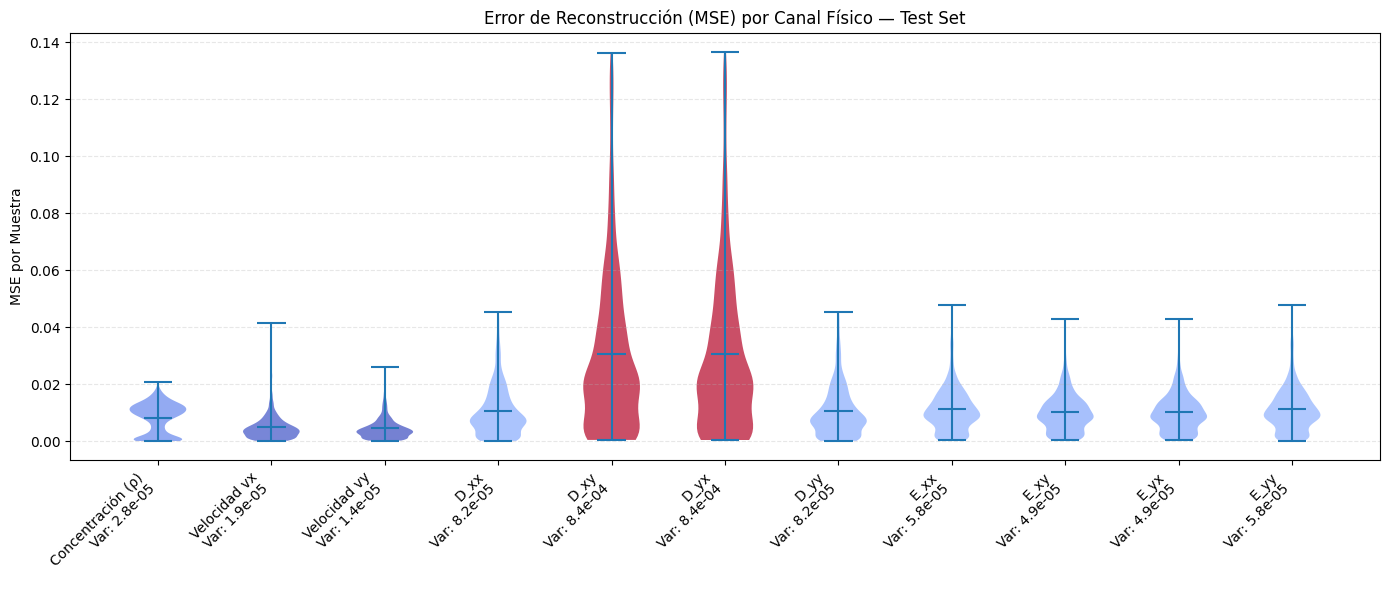


Canal                     |  MSE medio |   Varianza
-------------------------------------------------------
Concentración (ρ)         |   8.26e-03 |   2.75e-05
Velocidad vx              |   5.02e-03 |   1.93e-05
Velocidad vy              |   4.58e-03 |   1.44e-05
D_xx                      |   1.07e-02 |   8.24e-05
D_xy                      |   3.08e-02 |   8.38e-04
D_yx                      |   3.08e-02 |   8.39e-04
D_yy                      |   1.08e-02 |   8.21e-05
E_xx                      |   1.13e-02 |   5.76e-05
E_xy                      |   1.04e-02 |   4.93e-05
E_yx                      |   1.04e-02 |   4.91e-05
E_yy                      |   1.13e-02 |   5.76e-05

📊 MSE global (todos los canales): 1.3124e-02
📊 Total muestras evaluadas:       2106


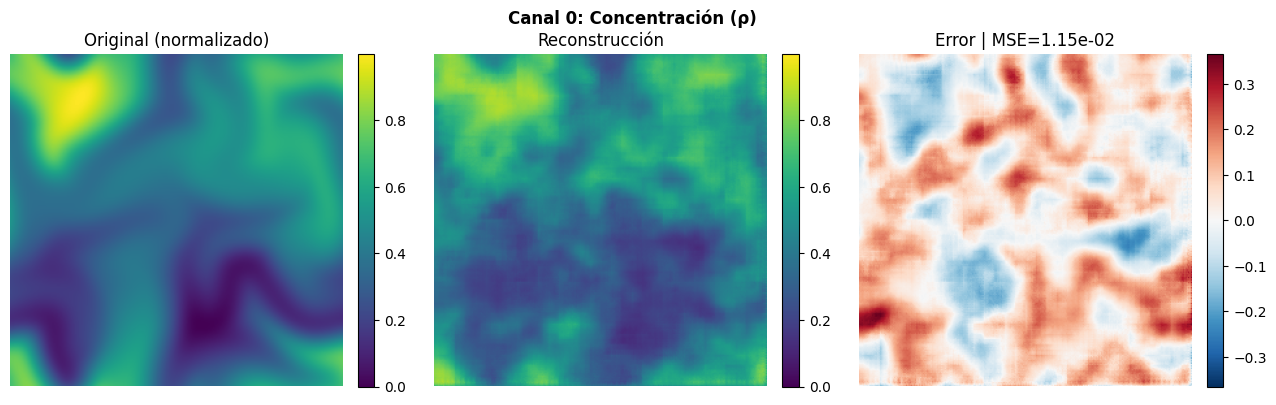

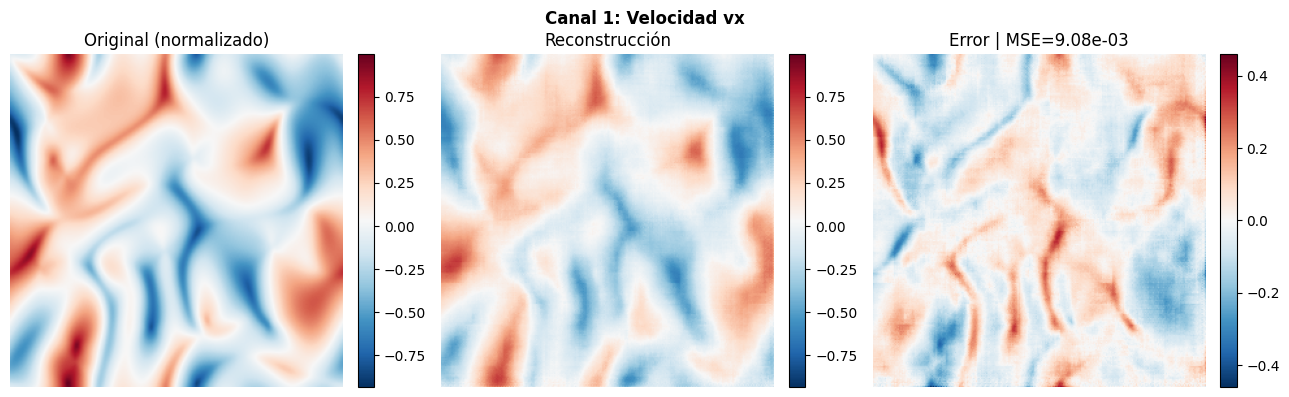

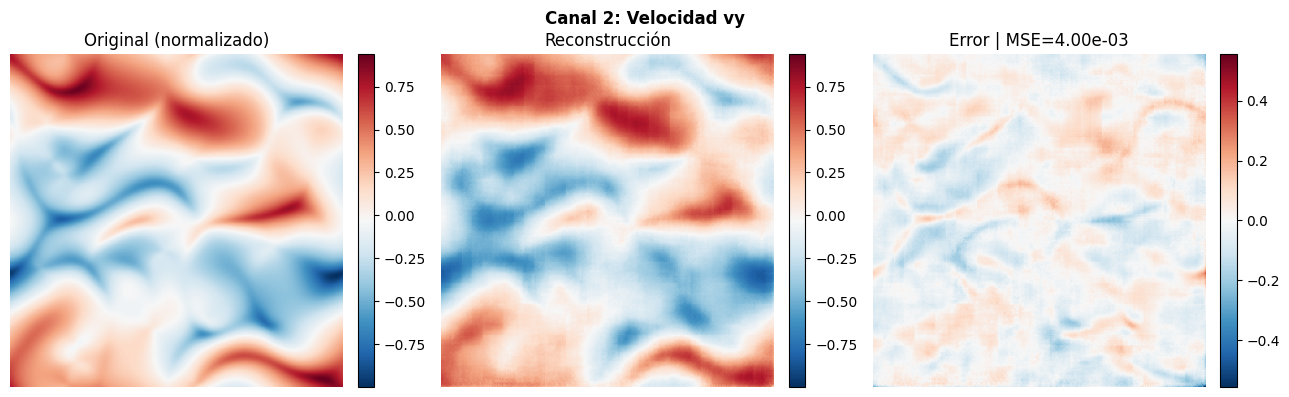

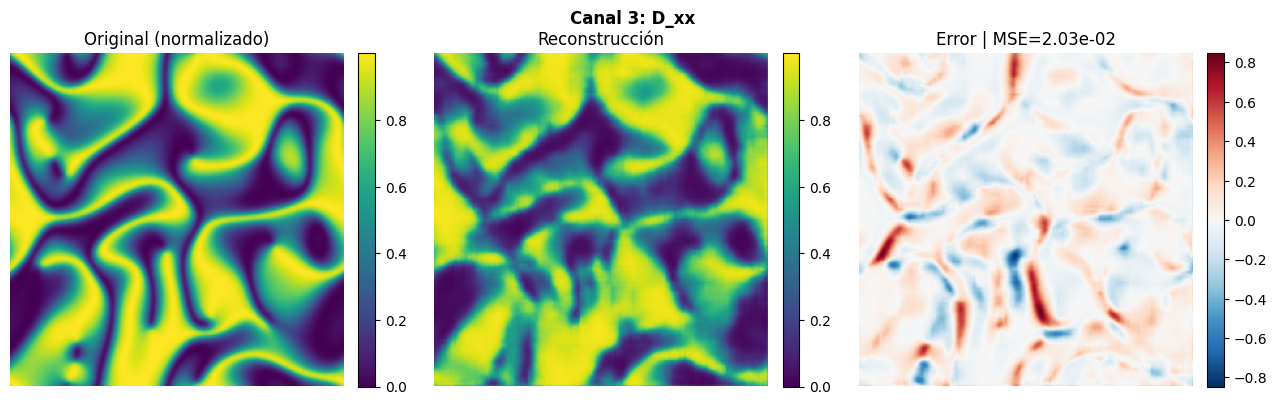

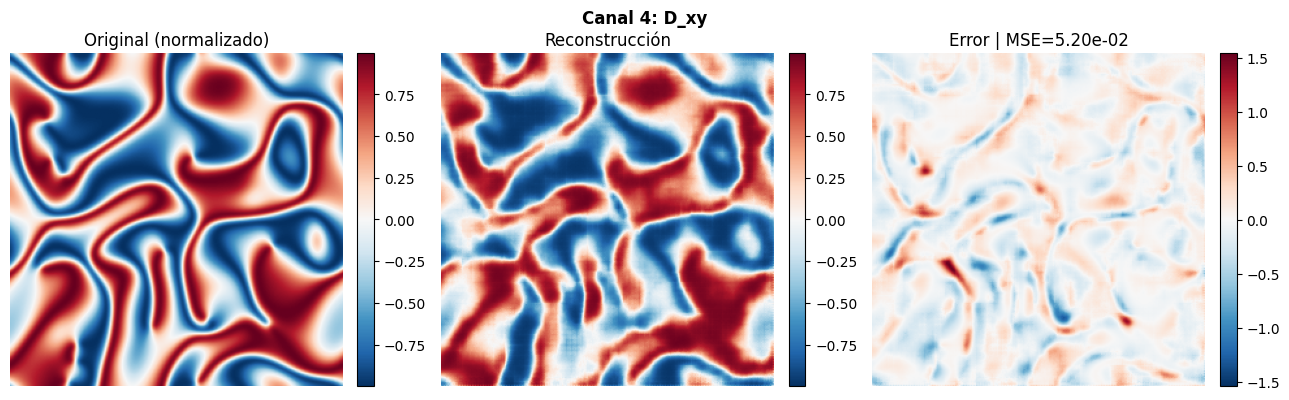

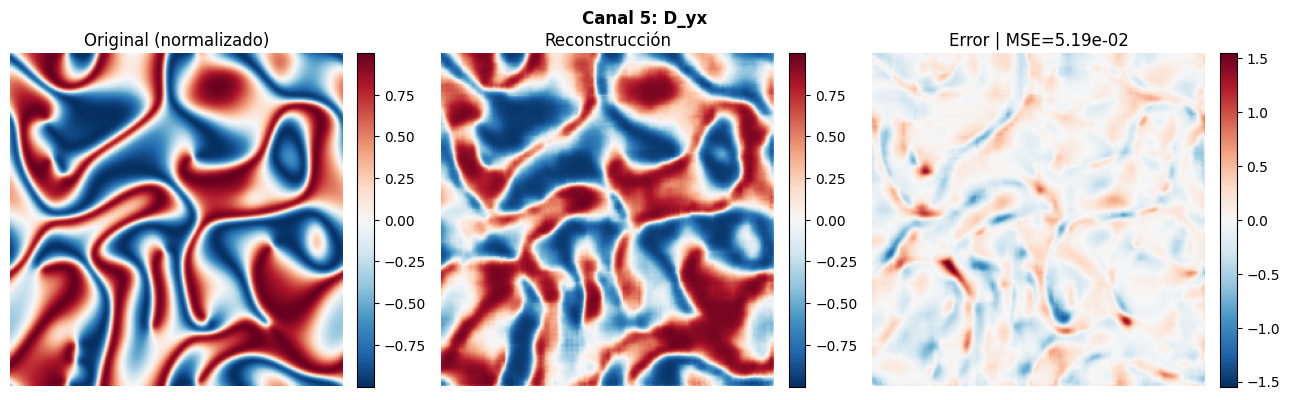

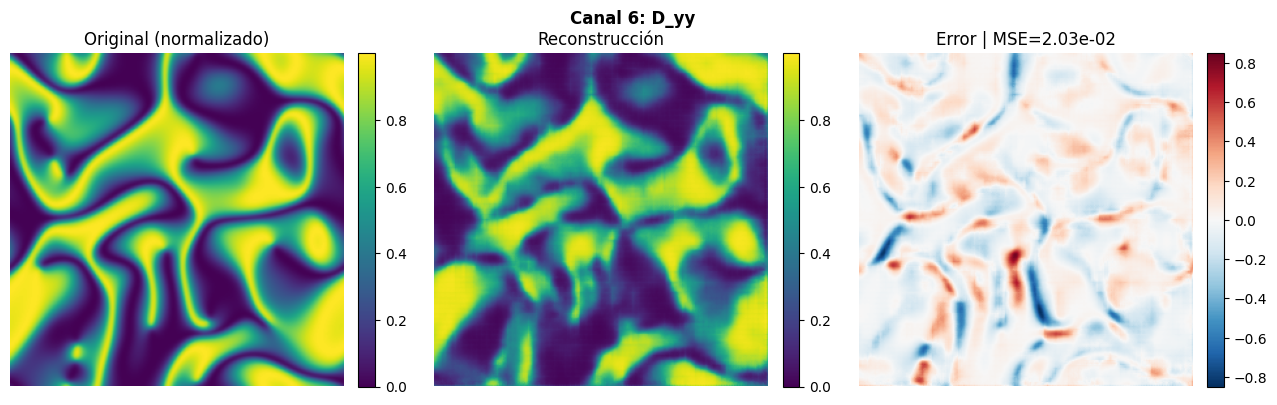

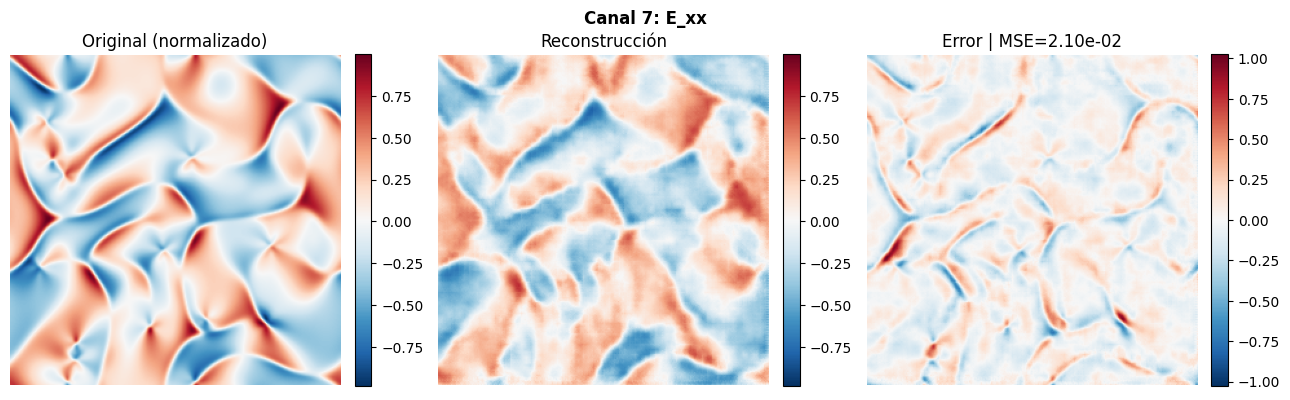

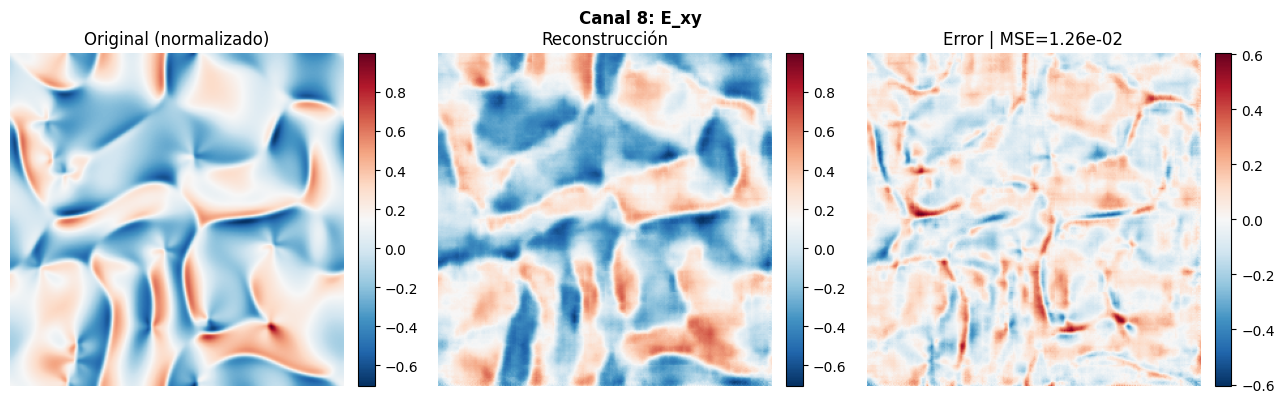

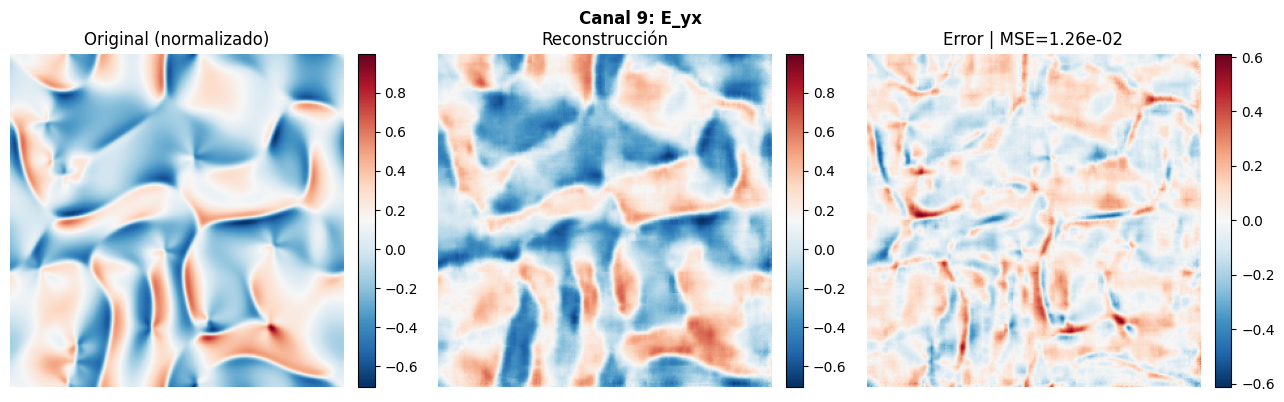

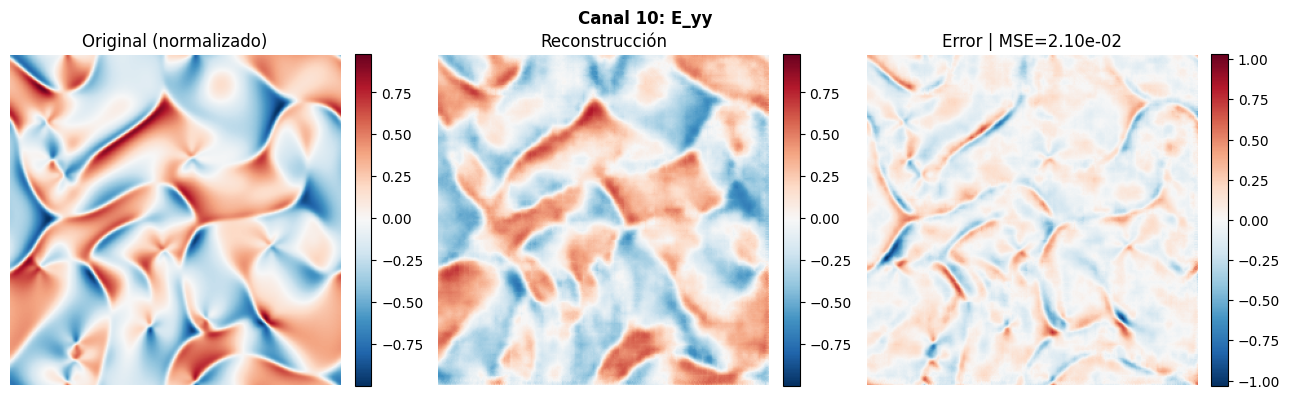

✅ Visualizaciones guardadas.


In [3]:

# ============================================================
# CELDA 2 — EVALUACIÓN EN TEST SET
# ============================================================
from tqdm import tqdm
 
channel_names = [
    "Concentración (ρ)",
    "Velocidad vx", "Velocidad vy",
    "D_xx", "D_xy", "D_yx", "D_yy",
    "E_xx", "E_xy", "E_yx", "E_yy",
]
 
POSITIVE_CHANNELS_LIST  = [0, 3, 6]
SYMMETRIC_CHANNELS_LIST = [1, 2, 4, 5, 7, 8, 9, 10]
 
# ── Cargar modelo ──────────────────────────────────────────
test_dataset = WellDataset(**dataset_kwargs, well_split_name="test")
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=PIN_MEMORY,
)
 
model_eval = AE().to(device)
try:
    state_dict = torch.load("model_PINN_best.pth", map_location=device, weights_only=True)
    clean_sd   = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
    model_eval.load_state_dict(clean_sd)
    model_eval.eval()
    print("✅ Pesos cargados.")
except FileNotFoundError:
    print("❌ No se encontró el archivo de pesos.")
 
# ── Evaluación ─────────────────────────────────────────────
mse_accum     = torch.zeros(11, device=device)
all_errors    = []
total_samples = 0
VIS_BATCH_IDX = 3   # ← cambiar para ver otro batch
 
vis_batch_x  = None
vis_batch_xr = None
 
if device.type == "cuda":
    torch.cuda.empty_cache()
 
print("🧪 Evaluando por canal en test set...")
with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader, desc="Test", unit="batch")):
        x = fast_preprocess(batch, device)
 
        if use_amp:
            with torch.amp.autocast("cuda"):
                xr, _ = model_eval(x)
        else:
            xr, _ = model_eval(x)
 
        if i == VIS_BATCH_IDX:
            vis_batch_x  = x.cpu()
            vis_batch_xr = xr.cpu()
 
        err_per_sample = ((xr - x)**2).mean(dim=(2, 3))    # (B, 11)
        mse_accum     += err_per_sample.sum(dim=0)
        all_errors.append(err_per_sample.cpu())
        total_samples += x.size(0)
 
final_mse     = (mse_accum / total_samples).cpu().numpy()
all_errors_np = torch.cat(all_errors, dim=0).numpy()       # (N, 11)
 
# ── Violin plot ────────────────────────────────────────────
means     = all_errors_np.mean(axis=0)
variances = all_errors_np.var(axis=0)
 
fig, ax = plt.subplots(figsize=(14, 6))
parts = ax.violinplot(all_errors_np, showmeans=True, showextrema=True)
 
norm_means = (means - means.min()) / (means.max() - means.min() + 1e-8)
colors = plt.cm.coolwarm(norm_means)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
 
labels = [f"{name}\nVar: {v:.1e}" for name, v in zip(channel_names, variances)]
ax.set_xticks(range(1, 12))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("MSE por Muestra")
ax.set_title("Error de Reconstrucción (MSE) por Canal Físico — Test Set")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("violin_mse_channels.png", dpi=150)
plt.show()
 
# ── Tabla ──────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Canal':<25} | {'MSE medio':>10} | {'Varianza':>10}")
print("-"*55)
for name, m, v in zip(channel_names, means, variances):
    print(f"{name:<25} | {m:>10.2e} | {v:>10.2e}")
print("="*55)
print(f"\n📊 MSE global (todos los canales): {final_mse.mean():.4e}")
print(f"📊 Total muestras evaluadas:       {total_samples}")
 
# ── Visualización por canal ────────────────────────────────
sim = 0   # índice dentro del batch VIS_BATCH_IDX
 
for i in range(11):
    img  = vis_batch_x[sim,  i, :, :].numpy()
    imgr = vis_batch_xr[sim, i, :, :].numpy()
    diff = imgr - img
 
    is_positive = i in POSITIVE_CHANNELS_LIST
    cmap_field  = "viridis" if is_positive else "RdBu_r"
 
    vmin = min(img.min(), imgr.min())
    vmax = max(img.max(), imgr.max())
 
    diff_abs = max(abs(diff.min()), abs(diff.max()))
    diff_abs = diff_abs if diff_abs > 1e-8 else 1e-8
 
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
 
    im0 = axes[0].imshow(img,  cmap=cmap_field, vmin=vmin, vmax=vmax)
    axes[0].set_title("Original (normalizado)")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
 
    im1 = axes[1].imshow(imgr, cmap=cmap_field, vmin=vmin, vmax=vmax)
    axes[1].set_title("Reconstrucción")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
 
    im2 = axes[2].imshow(diff, cmap="RdBu_r", vmin=-diff_abs, vmax=diff_abs)
    axes[2].set_title(f"Error | MSE={((diff**2).mean()):.2e}")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
 
    fig.suptitle(f"Canal {i}: {channel_names[i]}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"recon_canal_{i:02d}.png", dpi=150, bbox_inches="tight")
    plt.show()
 
print("✅ Visualizaciones guardadas.")
 
 

2026-08-06 09:59:47.985861: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-06 09:59:48.280093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-06 09:59:49.239778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


📐 Calculando escalares físicos...


Escalares: 100%|██████████| 9/9 [00:13<00:00,  1.53s/it]


✅ Escalares calculados para 2106 muestras.


Codificando latente: 100%|██████████| 17/17 [00:08<00:00,  2.02it/s]


✅ 2106 muestras codificadas | shape: (2106, 1024)
📊 Varianza explicada PC1+PC2: 7.4%


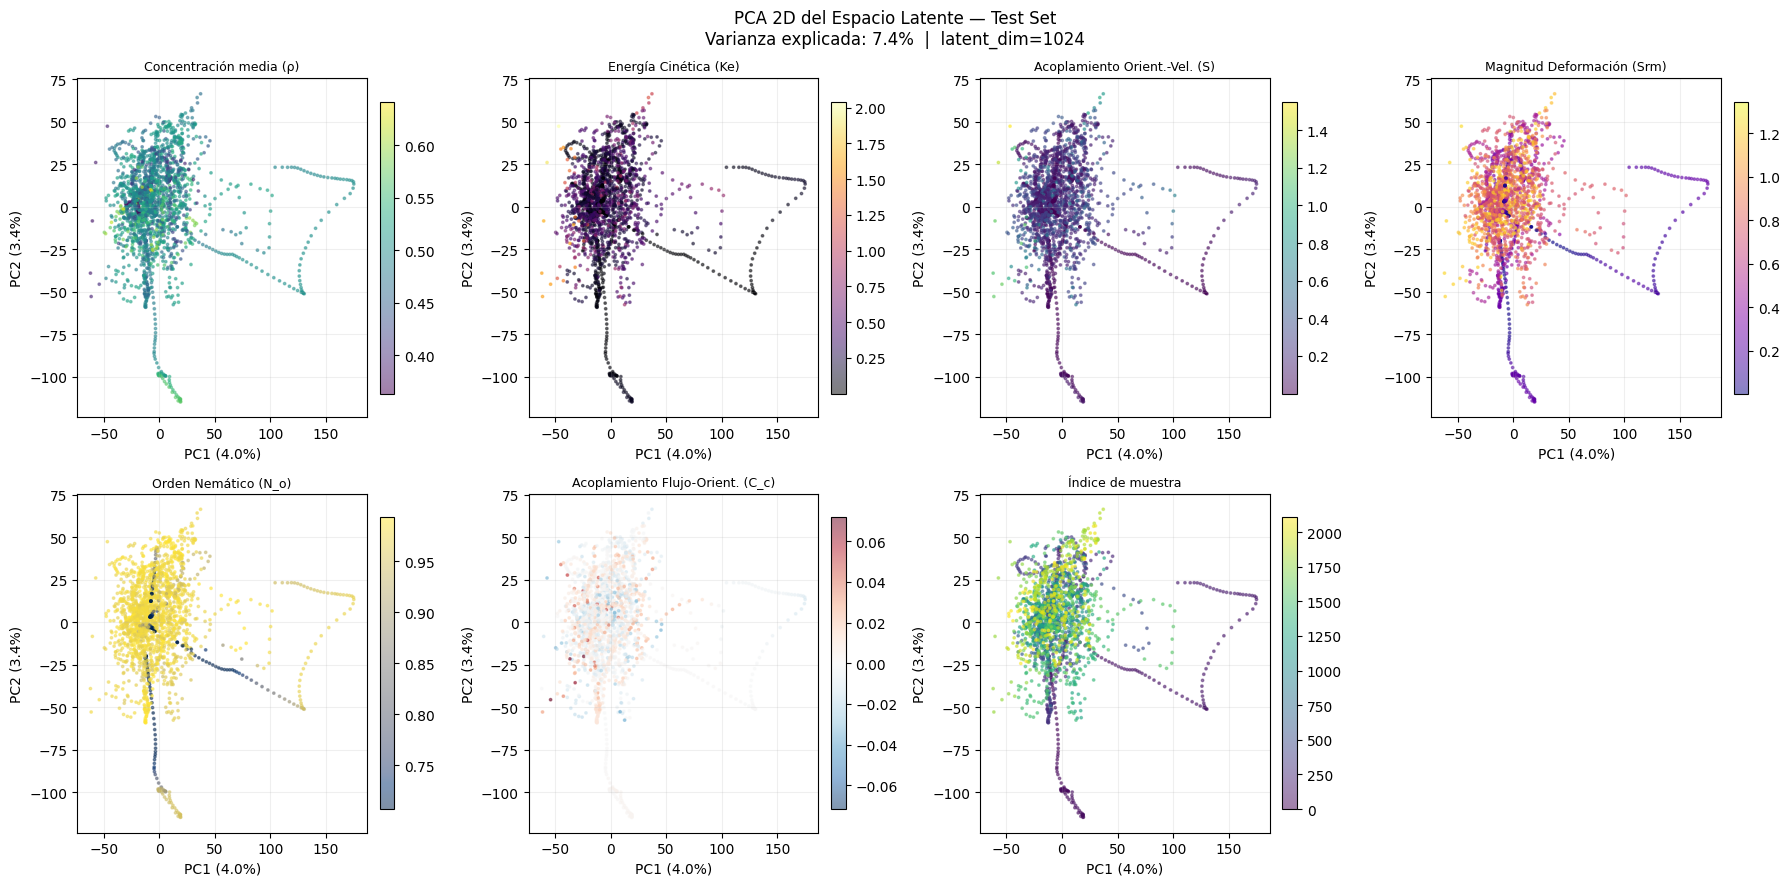

📊 Varianza explicada PC1+PC2+PC3: 10.5%


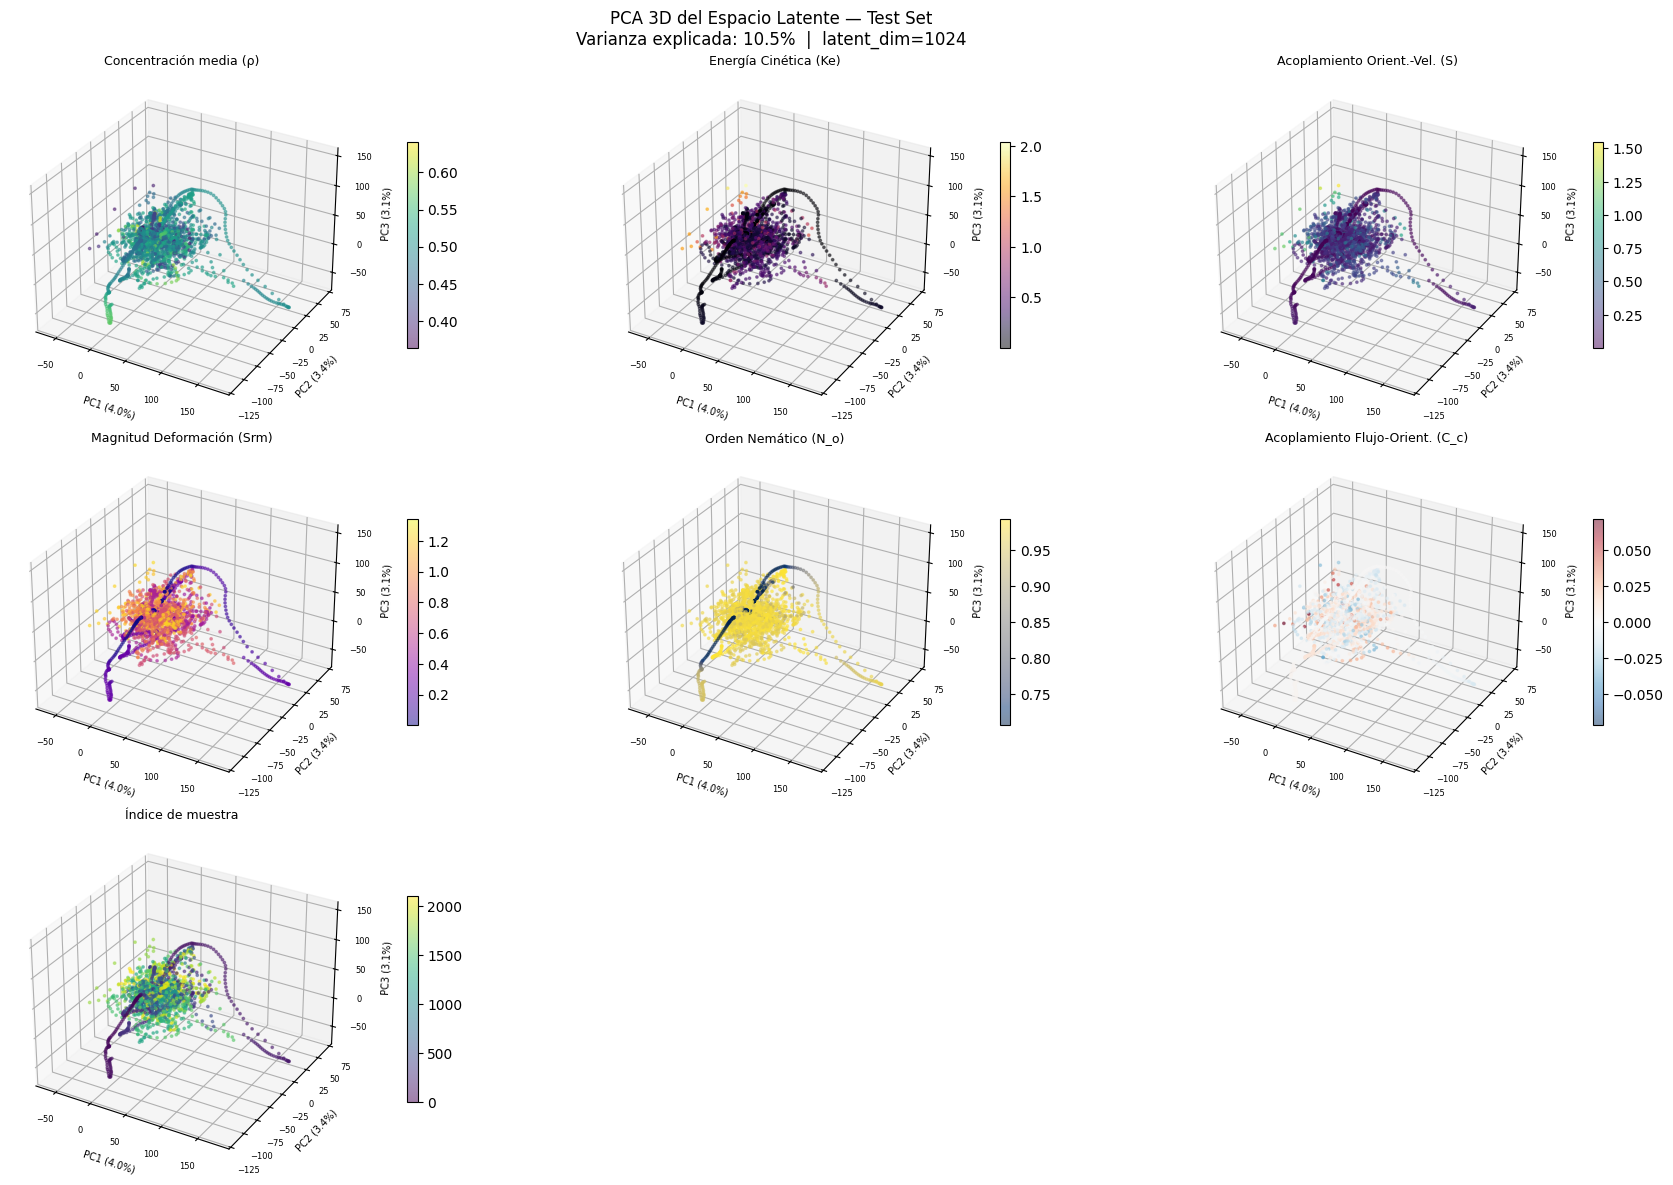

🗺️  Ajustando UMAP (puede tardar unos minutos)...


/home/itachi/miniconda3/envs/ml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP listo: (2106, 2)


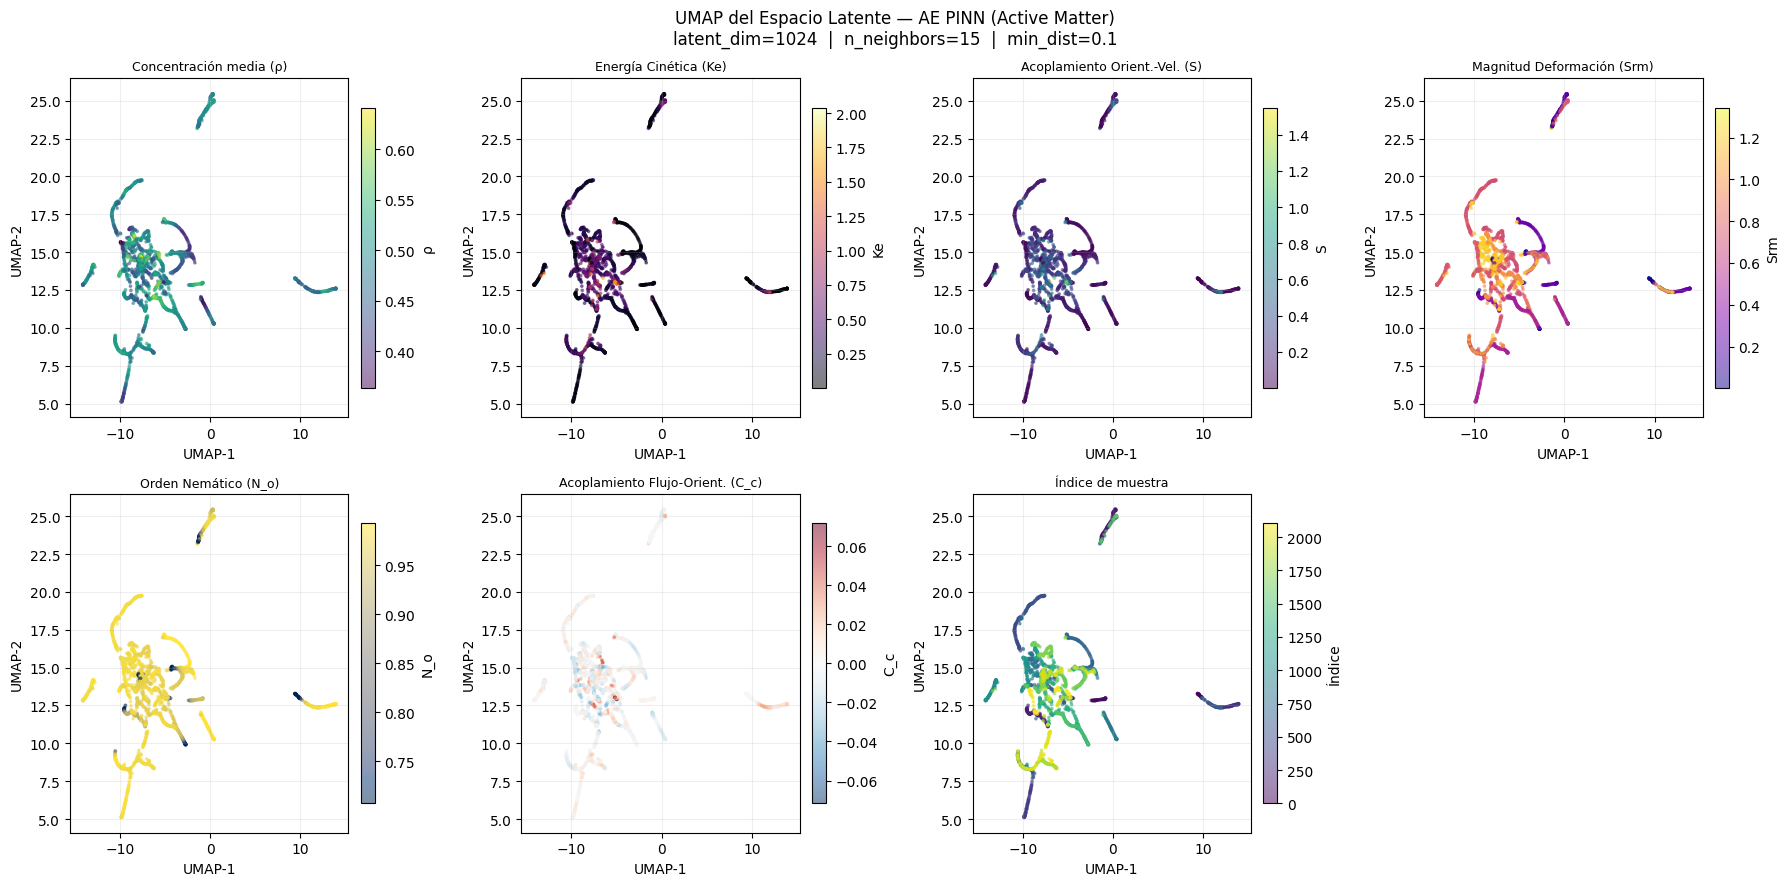

In [4]:

# ============================================================
# CELDA 3 — PCA + UMAP DEL ESPACIO LATENTE
# ============================================================
from tqdm import tqdm
from sklearn.decomposition import PCA
import umap
 
N = len(test_dataset)
 
mc  = np.zeros(N, dtype=np.float32)  # concentración media (normalizada)
Ke  = np.zeros(N, dtype=np.float32)  # energía cinética
S   = np.zeros(N, dtype=np.float32)  # acoplamiento orientación-velocidad
Srm = np.zeros(N, dtype=np.float32)  # magnitud del strain-rate
N_o = np.zeros(N, dtype=np.float32)  # orden nemático (norma de D)
C_c = np.zeros(N, dtype=np.float32)  # acoplamiento flujo-orientación
T   = np.zeros(N, dtype=np.float32)  # índice de muestra
 
scalar_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False,
    num_workers=0, pin_memory=False,
)
 
ptr = 0
print("📐 Calculando escalares físicos...")
for batch in tqdm(scalar_loader, desc="Escalares"):
    x_raw  = batch["input_fields"].squeeze(1)           # (B, H, W, 11) raw
    # FIX: mc sobre datos normalizados (concentration raw ≈ 1.0 constante)
    x_norm = fast_preprocess(batch, device).permute(0, 2, 3, 1).cpu()
    B = x_raw.size(0)
 
    vx  = x_raw[..., 1];  vy  = x_raw[..., 2]
    dxx = x_raw[..., 3];  dxy = x_raw[..., 4]
    dyx = x_raw[..., 5];  dyy = x_raw[..., 6]
    Exx = x_raw[..., 7];  Exy = x_raw[..., 8]
    Eyx = x_raw[..., 9];  Eyy = x_raw[..., 10]
 
    mc [ptr:ptr+B] = x_norm[..., 0].mean(dim=(1, 2)).numpy()
    Ke [ptr:ptr+B] = (0.5 * (vx**2 + vy**2)).mean(dim=(1, 2)).numpy()
    S  [ptr:ptr+B] = ((dxx * vy - dyy * vx)**2).mean(dim=(1, 2)).numpy()
    Srm[ptr:ptr+B] = torch.sqrt(Exx**2 + 2*Exy*Eyx + Eyy**2).mean(dim=(1, 2)).numpy()
    N_o[ptr:ptr+B] = torch.sqrt(dxx**2 + dxy**2 + dyx**2 + dyy**2).mean(dim=(1, 2)).numpy()
    C_c[ptr:ptr+B] = (vx * dxx + vy * dyx).mean(dim=(1, 2)).numpy()
    T  [ptr:ptr+B] = np.arange(ptr, ptr + B, dtype=np.float32)
    ptr += B
 
print(f"✅ Escalares calculados para {N} muestras.")
 
# ── Espacio latente ────────────────────────────────────────
Z_list = []
model_eval.eval()
 
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Codificando latente"):
        x = fast_preprocess(batch, device)
        if use_amp:
            with torch.amp.autocast("cuda"):
                z = model_eval.encode(x)
        else:
            z = model_eval.encode(x)
        Z_list.append(z.cpu())
 
X_latente = torch.cat(Z_list, dim=0).numpy()
print(f"✅ {len(X_latente)} muestras codificadas | shape: {X_latente.shape}")
 
cc_abs = np.abs(C_c).max()
 
configs = [
    (mc,  "viridis", None,    None,    "Concentración media (ρ)"),
    (Ke,  "inferno", None,    None,    "Energía Cinética (Ke)"),
    (S,   "viridis", None,    None,    "Acoplamiento Orient.-Vel. (S)"),
    (Srm, "plasma",  None,    None,    "Magnitud Deformación (Srm)"),
    (N_o, "cividis", None,    None,    "Orden Nemático (N_o)"),
    (C_c, "RdBu_r",  -cc_abs, cc_abs,  "Acoplamiento Flujo-Orient. (C_c)"),
    (T,   "viridis", None,    None,    "Índice de muestra"),
]
 
# ── PCA 2D ────────────────────────────────────────────────
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_latente)
var_explained = pca.explained_variance_ratio_[:2].sum() * 100
print(f"📊 Varianza explicada PC1+PC2: {var_explained:.1f}%")
 
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
 
for ax, (data, cmap, vmin, vmax, title) in zip(axes, configs):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=data, cmap=cmap, vmin=vmin, vmax=vmax,
                    s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.2)
 
axes[-1].set_visible(False)
plt.suptitle(f"PCA 2D del Espacio Latente — Test Set\n"
             f"Varianza explicada: {var_explained:.1f}%  |  latent_dim={X_latente.shape[1]}",
             fontsize=12)
plt.tight_layout()
plt.savefig("pca_latent_scalars.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ── PCA 3D ────────────────────────────────────────────────
pca3  = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_latente)
vr     = pca3.explained_variance_ratio_
print(f"📊 Varianza explicada PC1+PC2+PC3: {vr.sum()*100:.1f}%")
 
# FIX: C_c usaba "viridis" en el 3D — corregido a "RdBu_r"
configs3 = [
    (mc,  "viridis", None,    None,    "Concentración media (ρ)"),
    (Ke,  "inferno", None,    None,    "Energía Cinética (Ke)"),
    (S,   "viridis", None,    None,    "Acoplamiento Orient.-Vel. (S)"),
    (Srm, "plasma",  None,    None,    "Magnitud Deformación (Srm)"),
    (N_o, "cividis", None,    None,    "Orden Nemático (N_o)"),
    (C_c, "RdBu_r",  -cc_abs, cc_abs,  "Acoplamiento Flujo-Orient. (C_c)"),
    (T,   "viridis", None,    None,    "Índice de muestra"),
]
 
fig = plt.figure(figsize=(18, 12))
for i, (data, cmap, vmin, vmax, title) in enumerate(configs3):
    ax = fig.add_subplot(3, 3, i + 1, projection="3d")
    sc = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
                    c=data, cmap=cmap, vmin=vmin, vmax=vmax,
                    s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.1, shrink=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f"PC1 ({vr[0]:.1%})", fontsize=7, labelpad=2)
    ax.set_ylabel(f"PC2 ({vr[1]:.1%})", fontsize=7, labelpad=2)
    ax.set_zlabel(f"PC3 ({vr[2]:.1%})", fontsize=7, labelpad=2)
    ax.tick_params(labelsize=6)
 
plt.suptitle(f"PCA 3D del Espacio Latente — Test Set\n"
             f"Varianza explicada: {vr.sum()*100:.1f}%  |  latent_dim={X_latente.shape[1]}",
             fontsize=12)
plt.tight_layout()
plt.savefig("pca3d_latent_scalars.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ── UMAP ──────────────────────────────────────────────────
print("🗺️  Ajustando UMAP (puede tardar unos minutos)...")
reducer = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric="euclidean", random_state=42, low_memory=False,
)
X_umap = reducer.fit_transform(X_latente)
print(f"✅ UMAP listo: {X_umap.shape}")
 
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
 
_labels = ["ρ", "Ke", "S", "Srm", "N_o", "C_c", "Índice"]
for i, ((data, cmap, vmin, vmax, title), lbl) in enumerate(zip(configs, _labels)):
    sp = axes[i].scatter(X_umap[:, 0], X_umap[:, 1],
                         c=data, cmap=cmap, vmin=vmin, vmax=vmax,
                         s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sp, ax=axes[i], label=lbl, fraction=0.046, pad=0.04)
    axes[i].set_title(title, fontsize=9)
    axes[i].set_xlabel("UMAP-1")
    axes[i].set_ylabel("UMAP-2")
    axes[i].grid(True, alpha=0.2)
 
axes[-1].set_visible(False)
plt.suptitle(f"UMAP del Espacio Latente — AE PINN (Active Matter)\n"
             f"latent_dim={X_latente.shape[1]}  |  n_neighbors=15  |  min_dist=0.1",
             fontsize=12)
plt.tight_layout()
plt.savefig("ae_umap_latent.png", dpi=150, bbox_inches="tight")
plt.show()
